# generate_scm_poisson_26()

This notebook presents the **generate scm poisson 26** research workflow and key analysis steps.

This scenario produces synthetic panel data with one treated unit and multiple donors. It uses a low-level **Poisson DGP** to simulate realistic discrete outcomes with time-varying exposure and latent rates.


# DGP math


The Data Generating Process (DGP) for the Poisson SCM scenario follows a hierarchical log-linear model for the mean $\mu$, with observations $y$ sampled from a Poisson distribution.


## 1.1 Donor units


For each donor unit $j$ at time $t$:
1. **Exposure** $E_{tj}$:
   $$\log(E_{tj}) = \alpha_j + \gamma_j (t - \bar{t}) + \epsilon_t^{\text{common\_exp}} + \epsilon_{tj}^{\text{donor\_exp}}$$
   where $\epsilon_t^{\text{common\_exp}}$ and $\epsilon_{tj}^{\text{donor\_exp}}$ are AR(1) processes.
2. **Mean** $\mu_{tj}$:
   $$\mu_{tj} = E_{tj} \cdot \exp(\eta_{tj})$$
   $$\eta_{tj} = \beta_j + \delta_j (t - \bar{t}) + \lambda_j S_t + L_t + \sum_{k} \phi_{jk} F_{tk} + \epsilon_{tj}^{\text{donor\_noise}}$$
   where:
   - $S_t$: monthly seasonality signal
   - $L_t$: common factor (macro log index, AR(1))
   - $F_{tk}$: latent factors (AR(1))
   - $\epsilon_{tj}^{\text{donor\_noise}}$: donor-specific AR(1) noise
3. **Outcome** $y_{tj}$:
   $$y_{tj} \sim \text{Poisson}(\mu_{tj})$$


## 1.2 Treated unit


The counterfactual mean $\mu_{t, cf}$ is a weighted combination of donors, potentially with a pre-fit mismatch:
$$\mu_{t, cf} = \left( \sum_j w_j \mu_{tj} \right) \cdot \exp(\epsilon_t^{\text{mismatch}})$$
where $w \sim \text{Dirichlet}(\alpha)$.

The treated mean $\mu_{t, treated}$ is:
$$\mu_{t, treated} = \mu_{t, cf} \cdot (1 + \tau_{t}^{\text{rate}})$$
where $\tau_{t}^{\text{rate}}$ follows a post-treatment ramp-in path:
$$\tau_{t_k}^{\text{rate}} = \left(\texttt{treatment\_effect\_rate} + \texttt{treatment\_effect\_slope}\cdot k\right)\left(1 - e^{-(k+1)/2.5}\right), \quad k=0,\dots,T_{post}-1,$$
and $\tau_{t}^{\text{rate}} = 0$ for all pre-treatment and intervention-anchor periods.

The outcomes $y_{t, cf}$ and $y_{t, treated}$ are coupled via a thinning/superposition property to maintain exact Poisson marginals while ensuring the realized effect is driven by the multiplier in expectation:
- $y_{t, cf} \sim \text{Poisson}(\mu_{t, cf})$
- If $\mu_{t, treated} \ge \mu_{t, cf}$:
  $$y_{t, treated} = y_{t, cf} + \Delta_t, \quad \Delta_t \sim \text{Poisson}(\mu_{t, treated} - \mu_{t, cf})$$
- If $\mu_{t, treated} < \mu_{t, cf}$:
  $$y_{t, treated}\mid y_{t, cf} \sim \text{Binomial}\left(y_{t, cf}, \frac{\mu_{t, treated}}{\mu_{t, cf}}\right)$$

This ensures that $E[y_{t, treated} - y_{t, cf} | \mu] = \mu_{t, treated} - \mu_{t, cf}$ and both marginals remain Poisson with means $\mu_{t, cf}$ and $\mu_{t, treated}$.


### 2. Oracle Treatment Effects (ATT)
The Average Treatment Effect on the Treated (ATT) is the average impact of the intervention across all post-treatment periods. In this synthetic scenario, we can calculate it in two ways:

1. **Realized ATT**: Based on observed vs. counterfactual outcomes.
$$ \text{ATT}_{realized} = \frac{1}{T_{post}} \sum_{t \in \text{Post}} (Y_t - Y_t^{(0)}) $$
In the data, this is the mean of `tau_realized_true` for the treated unit in post-periods.

2. **Mean ATT**: Based on the underlying population means (the "signal").
$$ \text{ATT}_{mean} = \frac{1}{T_{post}} \sum_{t \in \text{Post}} (\mu_t^{(1)} - \mu_t^{(0)}) $$
In the data, this is the mean of `tau_mean_true` for the treated unit in post-periods.


In [1]:
import numpy as np
import pandas as pd

from causalis.scenarios.synthetic_control import generate_scm_poisson_26

df = generate_scm_poisson_26(
    include_oracles=True,
    return_panel_data=False,
    seed=42,
)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()
relative_lift_realized = (post_treated["tau_realized_true"] / post_treated["y_cf"]).mean()

print(f"Ground-truth ATTE is {atte_true:.6f}")

Ground-truth ATTE is 2.750000


In [2]:
df.head()

,unit_id,calendar_time,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,4.0,4.0,0.0,6.150671,6.150671,0.0
1,donor_1,2000-02,0,9.0,9.0,0.0,5.599403,5.599403,0.0
2,donor_1,2000-03,0,4.0,4.0,0.0,4.978119,4.978119,0.0
3,donor_1,2000-04,0,6.0,6.0,0.0,5.777247,5.777247,0.0
4,donor_1,2000-05,0,8.0,8.0,0.0,5.685711,5.685711,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# EDA

In [4]:
paneldata

PanelDataSCM(df=(3885, 4), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2015-02', 'M'), last_post_period=Period('2015-05', 'M'), n_pre_periods=181, n_post_periods=4, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_3', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [5]:
from causalis.scenarios.synthetic_control.refutation import donors_diagnostics
donors_diagnostics(paneldata)

,donor,pre_mean,pre_std,pre_slope,corr_with_treated_pre,rmse_to_treated_pre,rmse_to_treated_pre_standardized,mean_diff_pre,slope_diff_pre,max_abs_gap_pre,is_never_treated,n_missing_pre,corr_rank,std_rmse_rank,slope_rank,composite_similarity_score,rank_by_similarity,notes
0,donor_4,9.762431,7.179154,0.115553,0.775096,6.670625,0.842433,-4.287293,-0.007929,20.0,True,0,4,5,1,0.883333,1,ok
1,donor_10,13.563536,7.602892,0.114674,0.755004,5.462074,0.689805,-0.486188,-0.008807,17.0,True,0,8,1,2,0.866667,2,ok
2,donor_18,16.220994,9.298357,0.140931,0.774548,6.310125,0.796906,2.171271,0.017449,20.0,True,0,5,3,3,0.866667,3,ok
3,donor_9,13.701657,6.733231,0.100152,0.731460,5.491832,0.693564,-0.348066,-0.023330,19.0,True,0,10,2,4,0.783333,4,ok
4,donor_1,10.646409,5.490006,0.079764,0.740206,6.329794,0.799390,-3.403315,-0.043717,20.0,True,0,9,4,6,0.733333,5,ok
5,donor_17,17.458564,10.886897,0.178779,0.770667,7.744183,0.978013,3.408840,0.055297,27.0,True,0,6,9,9,0.650000,6,ok
6,donor_19,10.453039,5.153367,0.073788,0.691311,6.765610,0.854429,-3.596685,-0.049693,23.0,True,0,12,6,7,0.633333,7,ok
7,donor_13,8.718232,5.794182,0.080950,0.681039,7.886978,0.996047,-5.331492,-0.042531,30.0,True,0,13,10,5,0.583333,8,ok
8,donor_8,9.198895,5.152288,0.070184,0.669963,7.623024,0.962712,-4.850829,-0.053298,23.0,True,0,14,8,8,0.550000,9,ok
9,donor_5,10.950276,5.267723,0.065347,0.609616,7.014192,0.885823,-3.099448,-0.058134,22.0,True,0,16,7,10,0.500000,10,ok


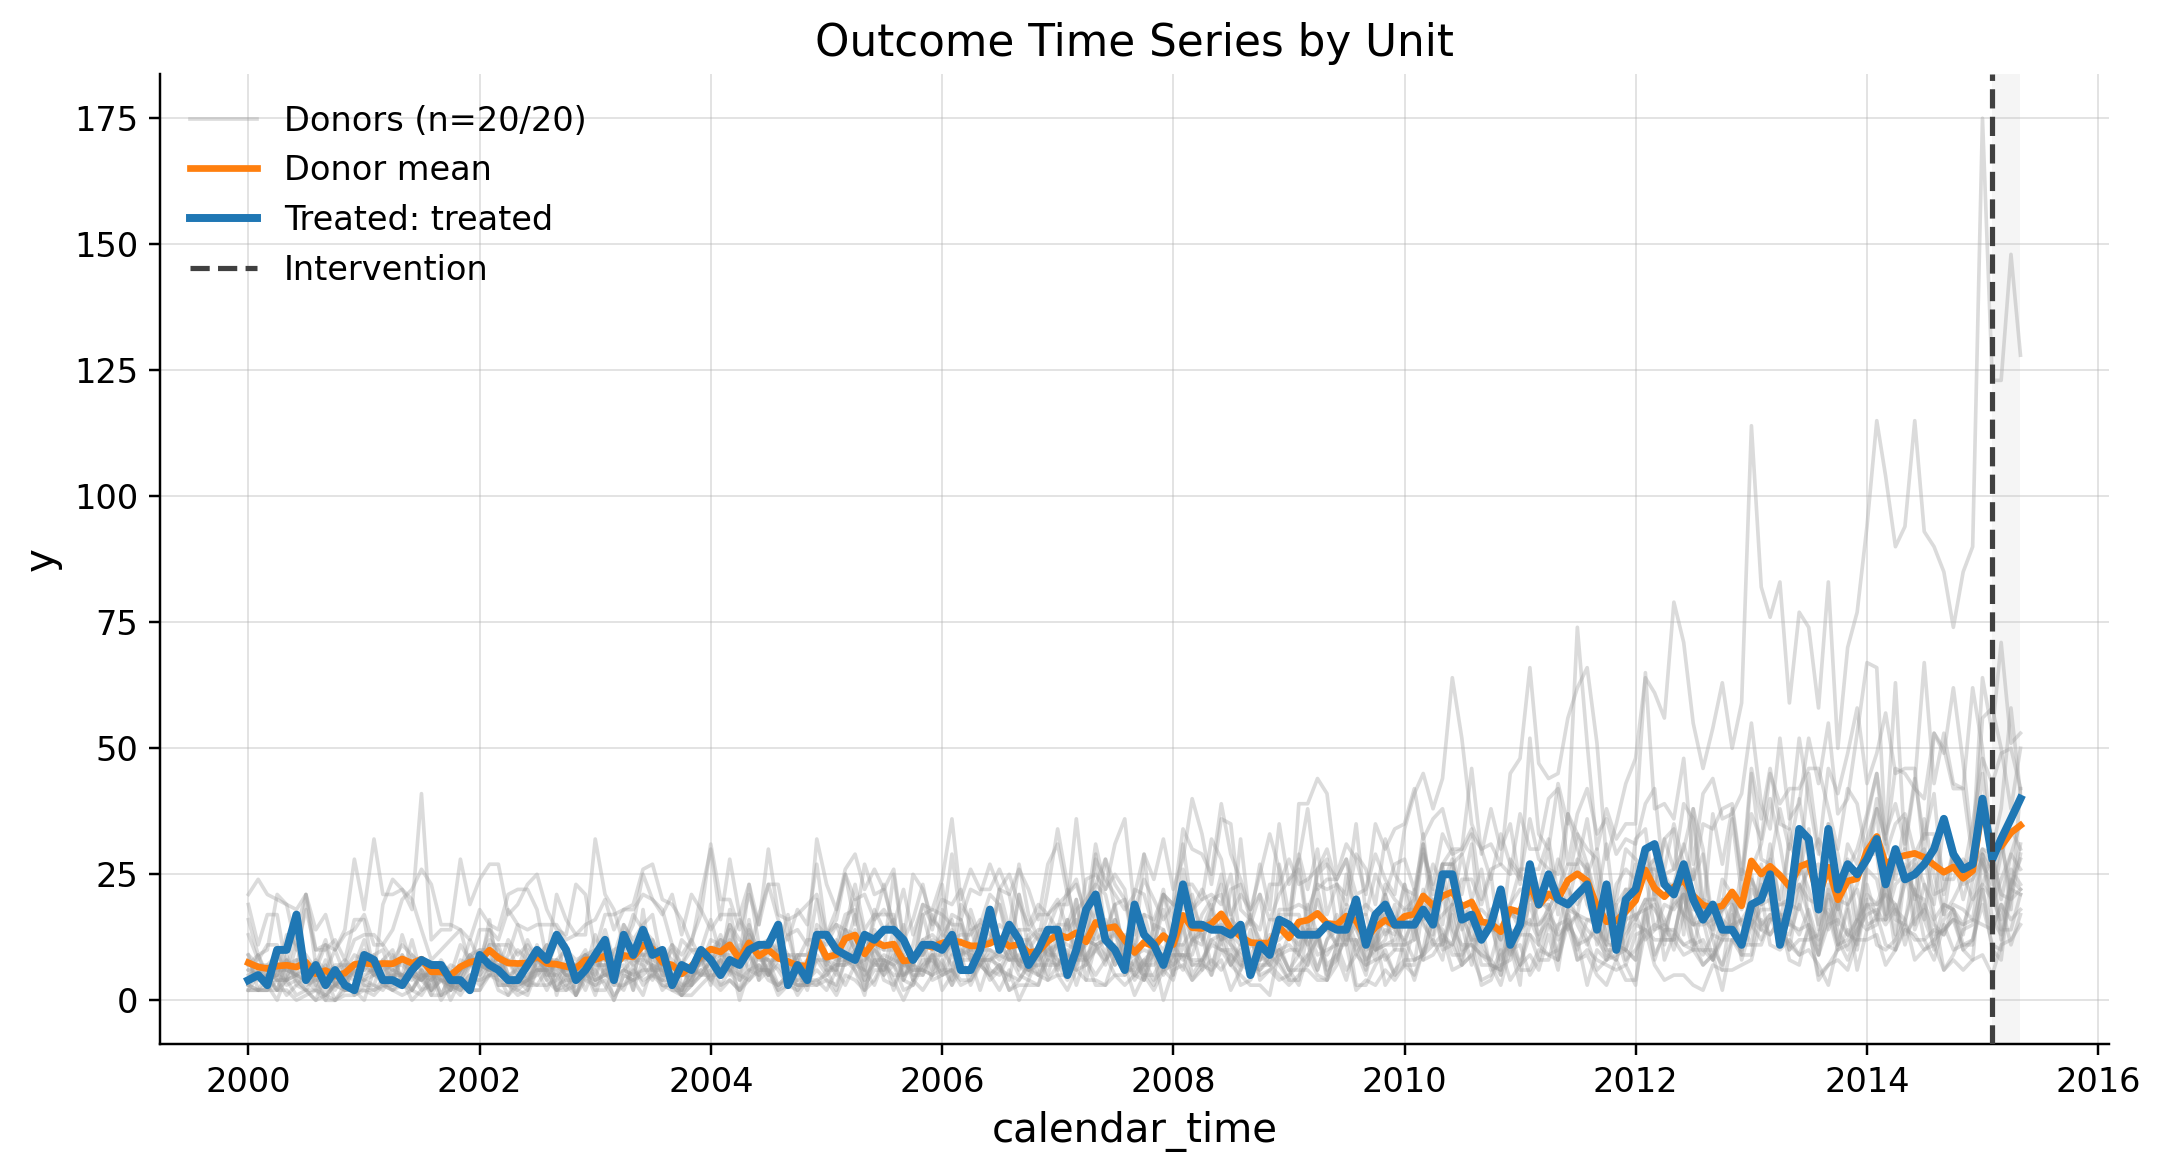

In [6]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)